In [1]:
import pandas as pd

In [2]:
path = '../data/processed/cleaned_data.csv'
dataset = pd.read_csv(path)

In [3]:
dataset.head(3)

,Geography_Germany,Geography_Spain,Gender_Male,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0.0,0.0,0.0,619,42,2,0.00,1,1,1,101348.88,1
1,0.0,1.0,0.0,608,41,1,83807.86,1,0,1,112542.58,0
2,0.0,0.0,0.0,502,42,8,159660.80,3,1,0,113931.57,1


In [4]:
clustering_dataset = dataset.drop('Exited', axis = 1)

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
scaler = StandardScaler()

In [7]:
clustering_dataset_scaled = pd.DataFrame(scaler.fit_transform(clustering_dataset), columns = scaler.get_feature_names_out())

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [9]:
wcss = []
silhoute = []
n_clusters = [i for i in range(2, 11)]

In [10]:
for n in n_clusters:
    temp_kmc = KMeans(n_clusters = n, init = 'k-means++', random_state = 42)
    temp_kmc.fit(clustering_dataset_scaled)
    wcss.append(temp_kmc.inertia_)
    silhoute.append(silhouette_score(clustering_dataset_scaled, labels = temp_kmc.labels_))

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

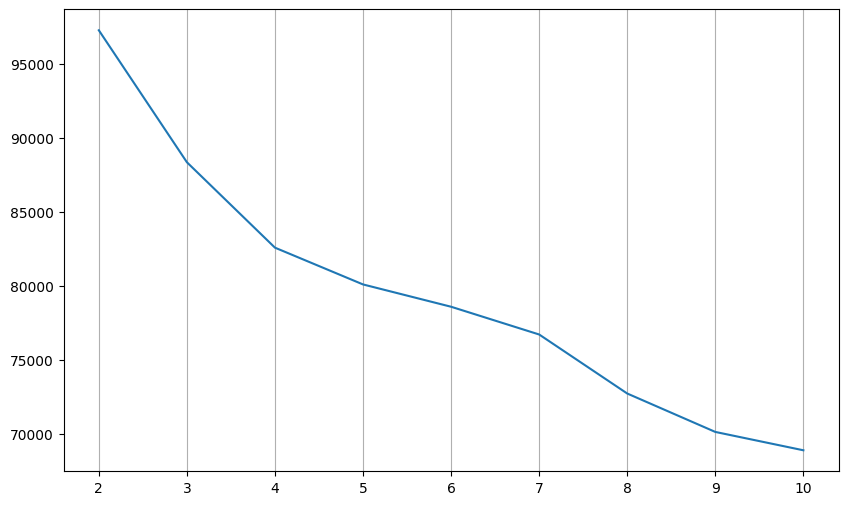

In [12]:
plt.figure(figsize = (10,6))
sns.lineplot(x = n_clusters, y = wcss)
plt.xticks(n_clusters)
plt.grid(axis = 'x')
plt.show()

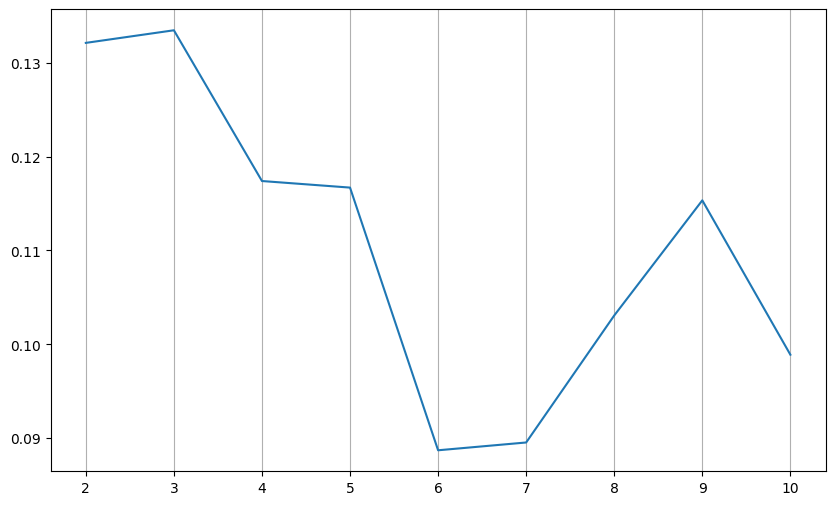

In [13]:
plt.figure(figsize = (10,6))
sns.lineplot(x = n_clusters, y = silhoute)
plt.xticks(n_clusters)
plt.grid(axis = 'x')
plt.show()

In [14]:
kmeans = KMeans(n_clusters = 3, init='k-means++', random_state = 42)

In [15]:
clustering_dataset['Cluster'] = kmeans.fit_predict(clustering_dataset_scaled)

In [20]:
from sklearn.decomposition import PCA

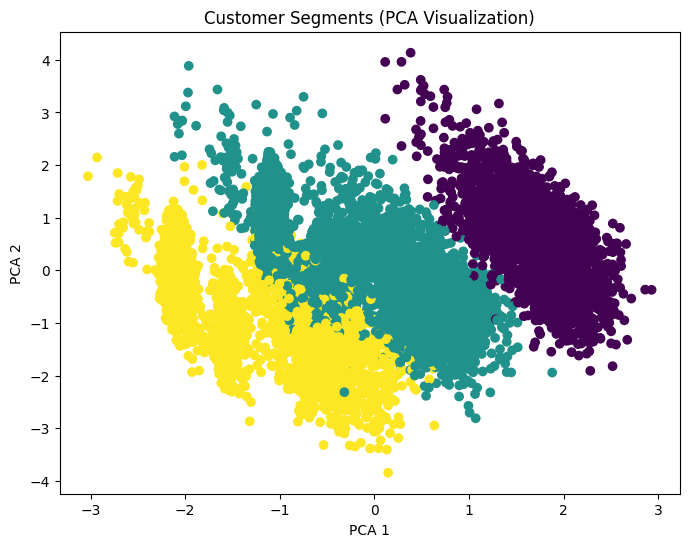

In [26]:
pca = PCA(n_components=2)
components = pca.fit_transform(clustering_dataset_scaled)
plt.figure(figsize = (8,6))
plt.scatter(components[:,0], components[:,1], c=clustering_dataset['Cluster'], cmap='viridis')
plt.title("Customer Segments (PCA Visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.savefig("../reports/pca_clusters.png", dpi=300, bbox_inches='tight')
plt.show()

In [25]:
clustering_dataset.groupby('Cluster').mean(numeric_only=True)

,Geography_Germany,Geography_Spain,Gender_Male,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
Cluster,,,,,,,,,,,
0,1.0,0.0,0.524512,651.453567,39.771622,5.009964,119730.116134,1.519729,0.713830,0.497409,101113.435102
1,0.0,0.0,0.549063,649.668329,38.511767,5.004587,62092.636516,1.530913,0.706621,0.516753,99899.180814
2,0.0,1.0,0.560355,651.333872,38.890997,5.032297,61818.147763,1.539362,0.694792,0.529673,99440.572281
